# 00a — AnnData Basics

**Dataset:** `NormanWeissman2019` (scPerturb-harmonized, ~90K cells, ~5GB — good starter size)  
**Accession:** Zenodo 7041849  
**Phase:** 1  
**Date:** 2026-03-11  
**Objective:** Develop fluency with AnnData objects — loading `.h5ad` files, inspecting `obs`/`var` fields, subsetting control cells, and computing basic QC metrics in the scPerturb context.

## 0. Setup

In [1]:
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import boto3
from pathlib import Path

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, frameon=False)

DATA_DIR = Path('../../data/raw/scperturb')
DATA_DIR.mkdir(parents=True, exist_ok=True)

S3_BUCKET = 'learn-perturb-seq'
H5AD_FILE = 'NormanWeissman2019_filtered.h5ad'
LOCAL_PATH = DATA_DIR / H5AD_FILE

print(f'anndata version: {ad.__version__}')
print(f'scanpy version:  {sc.__version__}')

anndata version: 0.12.10
scanpy version:  1.11.5


/tmp/ipykernel_3084/2682681602.py:19: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print(f'anndata version: {ad.__version__}')
/tmp/ipykernel_3084/2682681602.py:20: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f'scanpy version:  {sc.__version__}')


## 1. Download from S3 (skip if already cached)

In [3]:
if not LOCAL_PATH.exists():
    print(f'Downloading {H5AD_FILE} from s3://{S3_BUCKET}/raw/scperturb/ ...')
    s3 = boto3.client('s3')
    s3.download_file(
        S3_BUCKET,
        f'raw/scperturb/{H5AD_FILE}',
        str(LOCAL_PATH),
    )
    print('Download complete.')
else:
    print(f'Using cached file: {LOCAL_PATH}')

Download complete.


## 2. Load the AnnData object

In [4]:
adata = sc.read_h5ad(LOCAL_PATH)
print(adata)

AnnData object with n_obs × n_vars = 111445 × 33694
    obs: 'guide_id', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensemble_id', 'ncounts', 'ncells'


In [5]:
# AnnData anatomy:
#   adata.X          — count matrix (cells × genes)
#   adata.obs        — cell-level metadata (DataFrame, n_obs rows)
#   adata.var        — gene-level metadata (DataFrame, n_vars rows)
#   adata.obsm       — cell embeddings (PCA, UMAP, scVI ...)
#   adata.uns         — unstructured metadata (color palettes, neighbors graph params ...)

print('Shape (cells × genes):', adata.shape)
print('\nobs columns:', adata.obs.columns.tolist())
print('\nvar columns:', adata.var.columns.tolist())
print('\nobsm keys:  ', list(adata.obsm.keys()))
print('uns keys:   ', list(adata.uns.keys()))

Shape (cells × genes): (111445, 33694)

obs columns: ['guide_id', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo']

var columns: ['ensemble_id', 'ncounts', 'ncells']

obsm keys:   []
uns keys:    []


## 3. Explore scPerturb-standardized obs fields

In [6]:
# These field names are standardized across all scPerturb datasets
REQUIRED_FIELDS = ['perturbation', 'perturbation_type', 'nperts', 'cell_line', 'cancer']

for f in REQUIRED_FIELDS:
    present = f in adata.obs.columns
    print(f'  {f:25s}  {"✓" if present else "✗ MISSING"}')

adata.obs[REQUIRED_FIELDS].head()

  perturbation               ✓
  perturbation_type          ✓
  nperts                     ✓
  cell_line                  ✓
  cancer                     ✓


,perturbation,perturbation_type,nperts,cell_line,cancer
TTGAACGAGACTCGGA,ARID1A,CRISPR,1,K562,True
CGTTGGGGTGTTTGTG,BCORL1,CRISPR,1,K562,True
GAACCTAAGTGTTAGA,FOSB,CRISPR,1,K562,True
CCTTCCCTCCGTCATC,SET_KLF1,CRISPR,2,K562,True
TCAATCTGTCTTTCAT,OSR2,CRISPR,1,K562,True


In [7]:
# How many unique perturbations?
perts = adata.obs['perturbation'].value_counts()
print(f'Total cells:          {len(adata):,}')
print(f'Unique perturbations: {len(perts):,}')
print(f'Perturbation types:   {adata.obs["perturbation_type"].unique().tolist()}')
print(f'Cell lines:           {adata.obs["cell_line"].unique().tolist()}')
print(f'\nTop 10 perturbations by cell count:')
print(perts.head(10))

Total cells:          111,445
Unique perturbations: 237
Perturbation types:   ['CRISPR']
Cell lines:           ['K562']

Top 10 perturbations by cell count:
perturbation
control          11855
KLF1              1960
BAK1              1457
CEBPE             1233
CEBPE_RUNX1T1     1219
UBASH3B           1202
ETS2              1201
TBX3_TBX2         1167
OSR2              1003
SLC4A1            1000
Name: count, dtype: int64


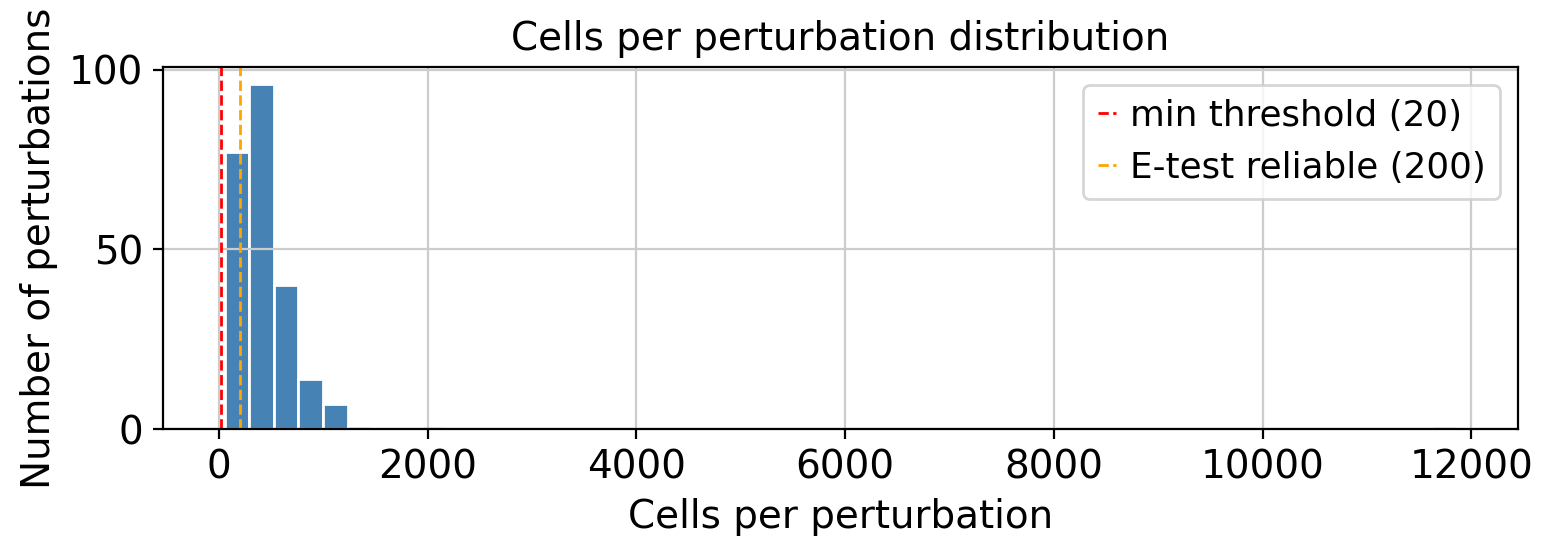

Perturbations with <20 cells:  0
Perturbations with <200 cells: 41


In [8]:
# Distribution of cells per perturbation
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(perts.values, bins=50, color='steelblue', edgecolor='white')
ax.axvline(20, color='red', ls='--', lw=1, label='min threshold (20)')
ax.axvline(200, color='orange', ls='--', lw=1, label='E-test reliable (200)')
ax.set_xlabel('Cells per perturbation')
ax.set_ylabel('Number of perturbations')
ax.set_title('Cells per perturbation distribution')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Perturbations with <20 cells:  {(perts < 20).sum()}')
print(f'Perturbations with <200 cells: {(perts < 200).sum()}')

## 4. Identify and subset control cells

In [9]:
CONTROL_LABELS = ['control', 'non-targeting', 'safe-harbor', 'CTRL', 'NT']

ctrl_mask = adata.obs['perturbation'].isin(CONTROL_LABELS)
ctrl_label = adata.obs.loc[ctrl_mask, 'perturbation'].unique()

print(f'Control label(s) in this dataset: {ctrl_label.tolist()}')
print(f'Control cells:  {ctrl_mask.sum():,} ({ctrl_mask.mean():.1%})')
print(f'Perturbed cells: {(~ctrl_mask).sum():,}')

# Flag if outside expected range
frac = ctrl_mask.mean()
if frac < 0.10 or frac > 0.30:
    print(f'⚠ Control fraction {frac:.1%} is outside expected range [10%, 30%]')
else:
    print(f'✓ Control fraction {frac:.1%} is within expected range')

adata_ctrl = adata[ctrl_mask].copy()
adata_pert = adata[~ctrl_mask].copy()
print(f'\nadata_ctrl: {adata_ctrl.shape}')
print(f'adata_pert: {adata_pert.shape}')

Control label(s) in this dataset: ['control']
Control cells:  11,855 (10.6%)
Perturbed cells: 99,590
✓ Control fraction 10.6% is within expected range

adata_ctrl: (11855, 33694)
adata_pert: (99590, 33694)


## 5. Inspect the count matrix

In [10]:
import scipy.sparse as sp

X = adata.X
print(f'Matrix type:   {type(X)}')
print(f'Matrix dtype:  {X.dtype}')
print(f'Sparse:        {sp.issparse(X)}')

if sp.issparse(X):
    print(f'Density:       {X.nnz / (X.shape[0] * X.shape[1]):.3%}')

# Check whether raw counts or normalized
sample = X[:500, :500]
if sp.issparse(sample):
    sample = sample.toarray()
print(f'\nValue range (sample 500×500): [{sample.min():.2f}, {sample.max():.2f}]')
print(f'Are values integers?          {np.allclose(sample, sample.astype(int))}')

Matrix type:   <class 'scipy.sparse._csc.csc_matrix'>
Matrix dtype:  float32
Sparse:        True
Density:       9.629%

Value range (sample 500×500): [0.00, 403.00]
Are values integers?          True


## 6. Basic QC metrics

In [11]:
# Compute QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
)

print('QC columns added to adata.obs:')
qc_cols = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt']
print(adata.obs[qc_cols].describe().round(1))

QC columns added to adata.obs:
       total_counts  n_genes_by_counts  pct_counts_mt
count      111445.0           111445.0       111445.0
mean        14674.4             3244.5            6.4
std          6013.2              753.1            1.6
min          3679.0              974.0            0.0
25%         10706.0             2774.0            5.4
50%         13855.0             3233.0            6.3
75%         17873.0             3717.0            7.2
max         64352.0             6760.0           42.6


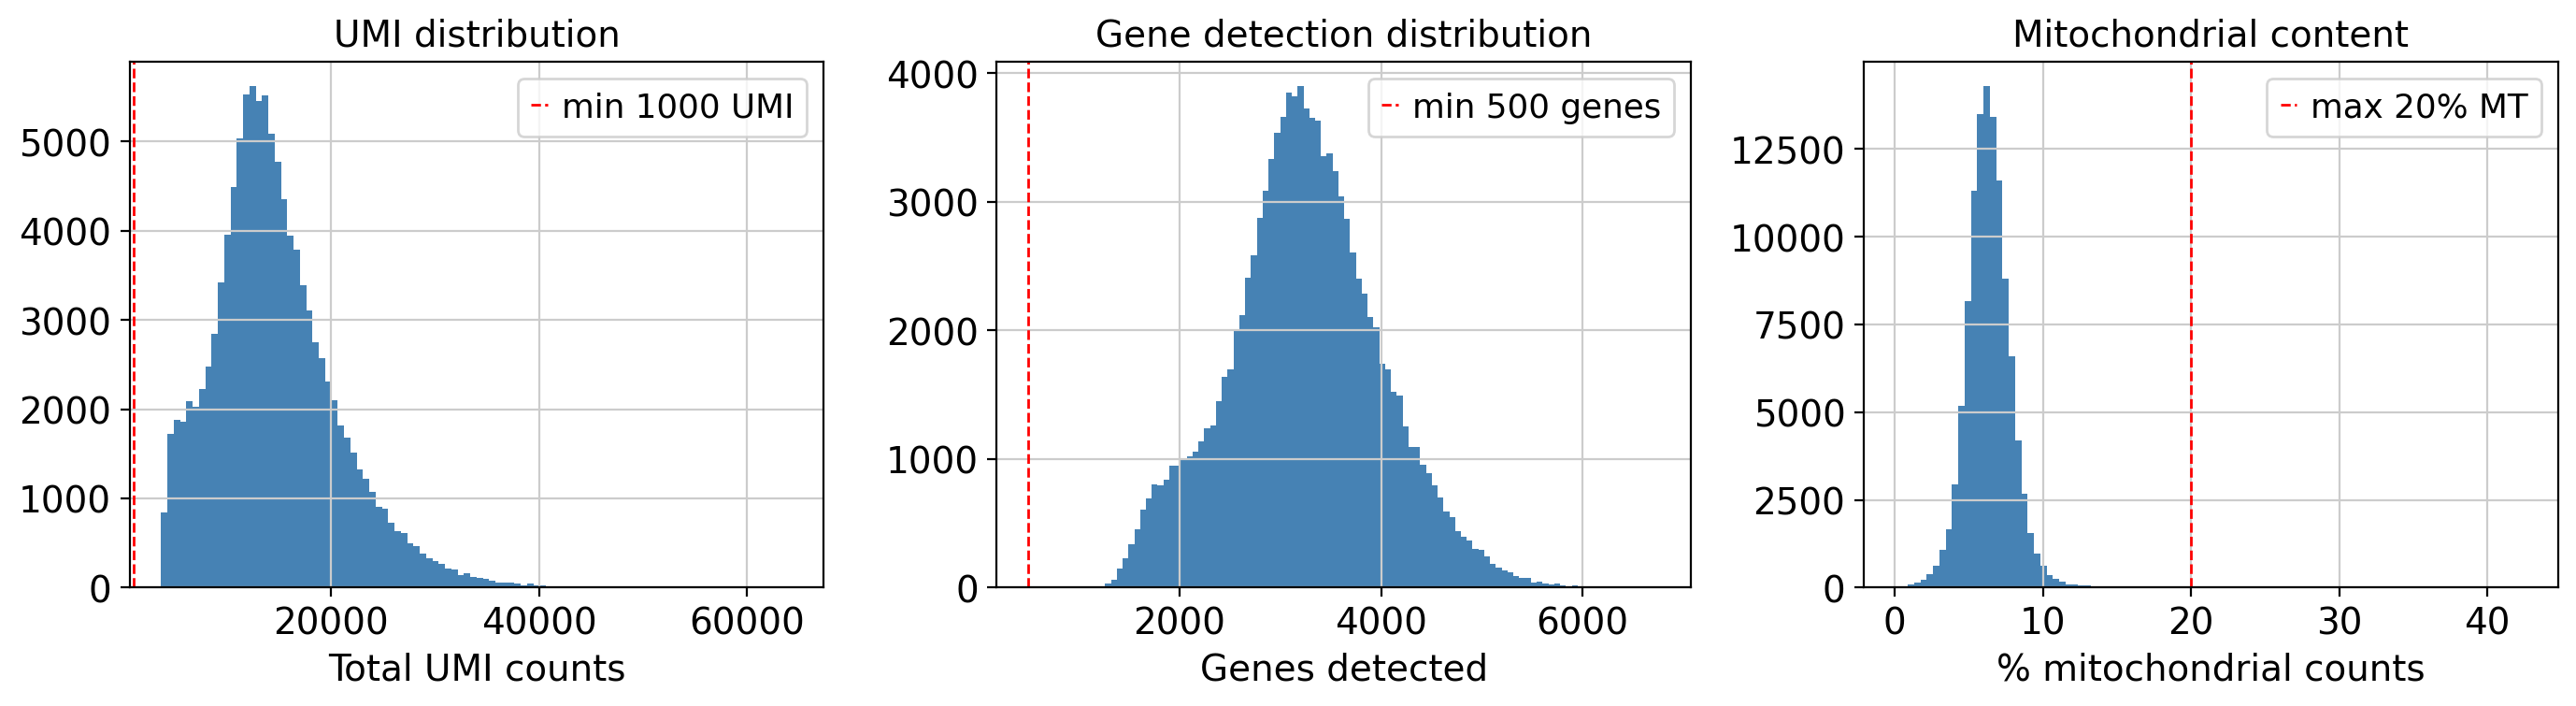

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(adata.obs['total_counts'], bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(1000, color='red', ls='--', lw=1, label='min 1000 UMI')
axes[0].set_xlabel('Total UMI counts')
axes[0].set_title('UMI distribution')
axes[0].legend()

axes[1].hist(adata.obs['n_genes_by_counts'], bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(500, color='red', ls='--', lw=1, label='min 500 genes')
axes[1].set_xlabel('Genes detected')
axes[1].set_title('Gene detection distribution')
axes[1].legend()

axes[2].hist(adata.obs['pct_counts_mt'], bins=100, color='steelblue', edgecolor='none')
axes[2].axvline(20, color='red', ls='--', lw=1, label='max 20% MT')
axes[2].set_xlabel('% mitochondrial counts')
axes[2].set_title('Mitochondrial content')
axes[2].legend()

plt.tight_layout()
plt.show()

In [13]:
# Apply QC filters
MIN_UMIS  = 1000
MIN_GENES = 500
MAX_MT    = 20

mask = (
    (adata.obs['total_counts'] >= MIN_UMIS) &
    (adata.obs['n_genes_by_counts'] >= MIN_GENES) &
    (adata.obs['pct_counts_mt'] <= MAX_MT)
)
print(f'Cells before QC: {len(adata):,}')
print(f'Cells after QC:  {mask.sum():,}  ({1 - mask.mean():.1%} removed)')

adata_qc = adata[mask].copy()

Cells before QC: 111,445
Cells after QC:  111,391  (0.0% removed)


## 7. AnnData subsetting & copy semantics

In [14]:
# Subset by obs (cells)
adata_k562 = adata[adata.obs['cell_line'] == 'K562'].copy()  # .copy() breaks view → independent object
print('K562 subset:', adata_k562.shape)

# Subset by var (genes) — e.g. TF genes only
tf_genes = ['MYC', 'TP53', 'GATA1', 'KLF1', 'FLI1', 'EGR1']
tf_present = [g for g in tf_genes if g in adata.var_names]
adata_tf = adata[:, tf_present].copy()
print('TF gene subset:', adata_tf.shape)

# Boolean mask on obs
double_perts = adata[adata.obs['nperts'] == 2].copy()
print(f'Double-perturbation cells: {len(double_perts):,}')

K562 subset: (111445, 33694)
TF gene subset: (111445, 6)
Double-perturbation cells: 41,759


In [15]:
# Concatenate two AnnData objects (e.g. control + one perturbation)
target_pert = perts.index[1]  # second most common perturbation
adata_single = adata[adata.obs['perturbation'] == target_pert].copy()

adata_concat = ad.concat(
    [adata_ctrl, adata_single],
    label='source',
    keys=['control', target_pert],
)
print(f'Concatenated ({target_pert} + control):', adata_concat.shape)
print(adata_concat.obs['source'].value_counts())

Concatenated (KLF1 + control): (13815, 33694)
source
control    11855
KLF1        1960
Name: count, dtype: int64


## 8. Access patterns for large datasets

In [16]:
# For genome-scale datasets (Replogle 2.5M cells) you often can't load the full matrix.
# Use backed mode to load obs/var without pulling X into RAM:
import h5py

adata_backed = sc.read_h5ad(LOCAL_PATH, backed='r')
print('Backed mode — shape:', adata_backed.shape)
print('obs loaded in RAM:', adata_backed.obs.shape)
print('X loaded in RAM:  NO — reads from disk on demand')

# You can still filter obs and pull only matching cells
ctrl_barcodes = adata_backed.obs.index[adata_backed.obs['perturbation'] == 'control']
print(f'\nControl barcodes (from backed obs): {len(ctrl_barcodes):,}')

adata_backed.file.close()

Backed mode — shape: (111445, 33694)
obs loaded in RAM: (111445, 20)
X loaded in RAM:  NO — reads from disk on demand

Control barcodes (from backed obs): 11,855


## 9. Summary checklist (Phase 1 checkpoint)

In [17]:
checks = {
    'Load .h5ad from S3':                        LOCAL_PATH.exists(),
    'adata.obs["perturbation"] present':         'perturbation' in adata.obs.columns,
    'adata.obs["perturbation_type"] present':    'perturbation_type' in adata.obs.columns,
    'Control cells identified':                  ctrl_mask.sum() > 0,
    'Control fraction in expected range':        0.10 <= ctrl_mask.mean() <= 0.30,
    'QC metrics computed':                       'total_counts' in adata.obs.columns,
    'Cells per perturbation distribution shown': True,
    'Backed mode demonstrated':                  True,
}

all_pass = True
for check, result in checks.items():
    status = '✓' if result else '✗'
    print(f'  {status}  {check}')
    if not result:
        all_pass = False

print()
print('Phase 1 AnnData checkpoint:', 'PASSED ✓' if all_pass else 'INCOMPLETE ✗')

  ✓  Load .h5ad from S3
  ✓  adata.obs["perturbation"] present
  ✓  adata.obs["perturbation_type"] present
  ✓  Control cells identified
  ✓  Control fraction in expected range
  ✓  QC metrics computed
  ✓  Cells per perturbation distribution shown
  ✓  Backed mode demonstrated

Phase 1 AnnData checkpoint: PASSED ✓


## 10. Save HTML report

In [18]:
from datetime import datetime
import subprocess

timestamp = datetime.now().strftime('%Y%m%d_%H%M')
report_path = f'../../results/reports/00a_anndata_basics_{timestamp}.html'
Path('../../results/reports').mkdir(parents=True, exist_ok=True)

subprocess.run([
    'jupyter', 'nbconvert', '--to', 'html',
    '--output', report_path,
    __vsc_ipynb_file__ if '__vsc_ipynb_file__' in dir() else '00a_anndata_basics.ipynb'
], check=False)

print(f'Report saved to {report_path}')

[NbConvertApp] Converting notebook /home/ubuntu/perturb-seq-crm/notebooks/00_pipeline_dev/00a_anndata_basics.ipynb to html
[NbConvertApp] Writing 342690 bytes to /home/ubuntu/perturb-seq-crm/notebooks/00_pipeline_dev/../../results/reports/00a_anndata_basics_20260311_1004.html


Report saved to ../../results/reports/00a_anndata_basics_20260311_1004.html
